# 05 — Single-head attention

Verifying `SelfAttentionHead` against PyTorch.

Order of cells:
1. Setup / imports
2. Build a tiny attention head, run a forward pass, inspect shapes
3. Compare nanograd vs PyTorch on the SAME weights — forward must match
4. Compare gradients — backward must match
5. Visualize the attention weights as a heatmap (Article 2 hero image candidate)

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import importlib, nanograd.engine, nanograd.ops, nanograd.tensor, nanograd.attention
for m in [nanograd.engine, nanograd.ops, nanograd.tensor, nanograd.attention]:
    importlib.reload(m)

import math
import random
import torch
import matplotlib.pyplot as plt
from nanograd.engine import Value
from nanograd.tensor import Tensor
from nanograd.attention import SelfAttentionHead

random.seed(1337)
torch.manual_seed(1337)
print('imports ok')

imports ok


## Test 1 — forward pass shapes

Build a 4-token, 8-dim input and run it through a head with `head_size=4`.
Output should be `(4, 4)`, weights should be `(4, 4)`.

In [2]:
T, n_embed, head_size = 4, 8, 4
head = SelfAttentionHead(n_embed, head_size)
X = Tensor.randn(T, n_embed)

out, weights = head(X)

print(f'X shape:       {X.shape}        expected ({T}, {n_embed})')
print(f'out shape:     {out.shape}      expected ({T}, {head_size})')
print(f'weights shape: {weights.shape}  expected ({T}, {T})')

assert X.shape == (T, n_embed)
assert out.shape == (T, head_size)
assert weights.shape == (T, T)

# Each row of weights should sum to 1 (softmaxed)
for i, row in enumerate(weights.data):
    s = sum(v.data for v in row)
    print(f'weights row {i} sums to {s:.6f}  (expect 1.0)')
    assert abs(s - 1.0) < 1e-5
print('\nSHAPES + ROW-SUMS PASS')

X shape:       (4, 8)        expected (4, 8)
out shape:     (4, 4)      expected (4, 4)
weights shape: (4, 4)  expected (4, 4)
weights row 0 sums to 1.000000  (expect 1.0)
weights row 1 sums to 1.000000  (expect 1.0)
weights row 2 sums to 1.000000  (expect 1.0)
weights row 3 sums to 1.000000  (expect 1.0)

SHAPES + ROW-SUMS PASS


## Test 2 — forward + backward vs PyTorch (same weights)

We rebuild the same attention head in PyTorch using the SAME weights as our nanograd head, then check that forward outputs and gradients match.

In [3]:
T, n_embed, head_size = 3, 4, 2
head = SelfAttentionHead(n_embed, head_size)
X = Tensor.randn(T, n_embed)

# Forward in nanograd
out_n, _ = head(X)
loss_n = sum((v for r in out_n.data for v in r), Value(0.0))
loss_n.backward()

# Mirror everything in PyTorch with identical numbers
X_t  = torch.tensor([[v.data for v in r] for r in X.data], requires_grad=True)
Wq_t = torch.tensor([[v.data for v in r] for r in head.W_q.data], requires_grad=True)
Wk_t = torch.tensor([[v.data for v in r] for r in head.W_k.data], requires_grad=True)
Wv_t = torch.tensor([[v.data for v in r] for r in head.W_v.data], requires_grad=True)

Q_t = X_t @ Wq_t
K_t = X_t @ Wk_t
V_t = X_t @ Wv_t
scores_t  = (Q_t @ K_t.T) / math.sqrt(head_size)
weights_t = torch.softmax(scores_t, dim=-1)
out_t = weights_t @ V_t
loss_t = out_t.sum()
loss_t.backward()

# Compare forwards
fwd_ok = all(
    abs(out_n.data[i][j].data - out_t[i][j].item()) < 1e-5
    for i in range(T) for j in range(head_size)
)
print(f'Forward match:    {"PASS" if fwd_ok else "FAIL"}')
print(f'  loss: nano={loss_n.data:.6f}  torch={loss_t.item():.6f}')

# Compare W_q gradients (the others are similar)
wq_ok = all(
    abs(head.W_q.data[i][j].grad - Wq_t.grad[i][j].item()) < 1e-4
    for i in range(n_embed) for j in range(head_size)
)
wk_ok = all(
    abs(head.W_k.data[i][j].grad - Wk_t.grad[i][j].item()) < 1e-4
    for i in range(n_embed) for j in range(head_size)
)
wv_ok = all(
    abs(head.W_v.data[i][j].grad - Wv_t.grad[i][j].item()) < 1e-4
    for i in range(n_embed) for j in range(head_size)
)
print(f'W_q grad match:   {"PASS" if wq_ok else "FAIL"}')
print(f'W_k grad match:   {"PASS" if wk_ok else "FAIL"}')
print(f'W_v grad match:   {"PASS" if wv_ok else "FAIL"}')

if fwd_ok and wq_ok and wk_ok and wv_ok:
    print('\nATTENTION VERIFIED vs PyTorch')
    print('PHASE 6 COMPLETE')

Forward match:    PASS
  loss: nano=-0.035293  torch=-0.035293
W_q grad match:   PASS
W_k grad match:   PASS
W_v grad match:   PASS

ATTENTION VERIFIED vs PyTorch
PHASE 6 COMPLETE


## Test 3 — visualize the attention pattern

The (T, T) attention weight matrix shows "how much does token i look at token j?".


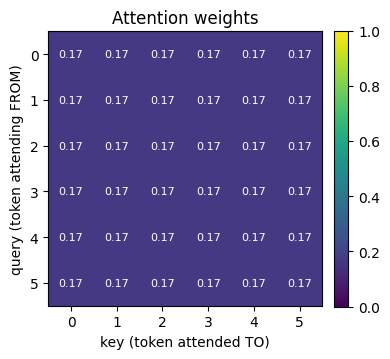

In [5]:
T, n_embed, head_size = 6, 8, 4
head = SelfAttentionHead(n_embed, head_size)
X = Tensor.randn(T, n_embed)
_, weights = head(X)

W = [[v.data for v in row] for row in weights.data]

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(W, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(T)); ax.set_yticks(range(T))
ax.set_xlabel('key (token attended TO)')
ax.set_ylabel('query (token attending FROM)')
ax.set_title('Attention weights')
for i in range(T):
    for j in range(T):
        ax.text(j, i, f'{W[i][j]:.2f}', ha='center', va='center', color='white', fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()